# HW08-09: Учебные датасеты
**Выбранный датасет:** EMNIST (Вариант B)
**Split:** balanced (47 классов: буквы + цифры)

In [32]:
# %% [markdown]
# ### 2.3.1. Импорты, seed и устройство

# %%
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import os

# --- Фиксация seed для воспроизводимости ---
SEED = 42

def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(SEED)

# --- Определение устройства ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [11]:
# %% [markdown]
# ### 2.3.2. Данные и DataLoader

# %%
# --- Трансформации ---
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # универсальная нормализация
])

# --- Загрузка EMNIST ---
train_full = torchvision.datasets.EMNIST(
    root='./data', 
    split="balanced",
    train=True, 
    download=True, 
    transform=transform
)

test_dataset = torchvision.datasets.EMNIST(
    root='./data', 
    split="balanced",
    train=False, 
    download=True, 
    transform=transform
)

In [12]:
# --- Разбиение train на train/val (80/20) ---
val_ratio = 0.2
train_size = int((1 - val_ratio) * len(train_full))
val_size = len(train_full) - train_size

train_dataset, val_dataset = random_split(
    train_full, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# --- DataLoader ---
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [13]:
# --- Sanity Check ---
print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Number of classes: {len(train_full.classes)}")

# Проверка формы батча
images, labels = next(iter(train_loader))
print(f"\nBatch shape (x): {images.shape}")
print(f"Batch shape (y): {labels.shape}")
print(f"Value range: [{images.min():.3f}, {images.max():.3f}]")

Train samples: 90240
Validation samples: 22560
Test samples: 18800
Number of classes: 47

Batch shape (x): torch.Size([64, 1, 28, 28])
Batch shape (y): torch.Size([64])
Value range: [-1.000, 1.000]


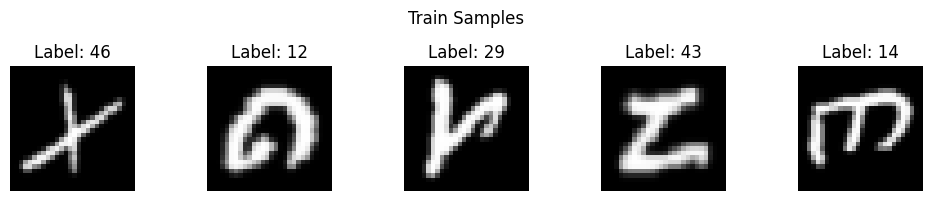

In [14]:
# --- Визуализация и сохранение примеров ---
os.makedirs('artifacts/figures', exist_ok=True)

def plot_samples(loader, title, path):
    images, labels = next(iter(loader))
    fig, axes = plt.subplots(1, 5, figsize=(10, 2))
    for i in range(5):
        img = images[i].squeeze().cpu().numpy()
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"Label: {labels[i].item()}")
        axes[i].axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.show()

plot_samples(train_loader, "Train Samples", "artifacts/figures/data_samples.png")

In [15]:
# %% [markdown]
# ### 2.3.3. Модель MLP и цикл обучения

# %%
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(MLP, self).__init__()
        self.flatten = nn.Flatten()
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Linear(hidden_size // 2, num_classes)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.network(x)
        return logits

# Параметры модели (47 классов для EMNIST!)
INPUT_SIZE = 28 * 28
HIDDEN_SIZE = 256
NUM_CLASSES = 47  # EMNIST balanced

model = MLP(INPUT_SIZE, HIDDEN_SIZE, NUM_CLASSES).to(device)
print(model)

MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=47, bias=True)
  )
)


In [16]:
# --- Loss и Optimizer ---
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# --- Функция обучения на одну эпоху ---
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    avg_loss = running_loss / len(loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

# --- Функция оценки ---
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_loss = running_loss / len(loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

In [17]:
# --- Параметры обучения ---
NUM_EPOCHS = 10
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

print("Starting training...")

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}%")

print("Training finished.")

Starting training...


Epoch 1/10 | Train Loss: 1.1842 Acc: 65.34% | Val Loss: 0.7828 Acc: 75.51%
Epoch 2/10 | Train Loss: 0.6794 Acc: 78.28% | Val Loss: 0.6511 Acc: 79.20%
Epoch 3/10 | Train Loss: 0.5734 Acc: 80.98% | Val Loss: 0.5846 Acc: 81.02%
Epoch 4/10 | Train Loss: 0.5168 Acc: 82.60% | Val Loss: 0.5535 Acc: 82.16%
Epoch 5/10 | Train Loss: 0.4807 Acc: 83.53% | Val Loss: 0.5438 Acc: 81.85%
Epoch 6/10 | Train Loss: 0.4551 Acc: 84.20% | Val Loss: 0.5318 Acc: 82.42%
Epoch 7/10 | Train Loss: 0.4330 Acc: 84.71% | Val Loss: 0.5379 Acc: 82.50%
Epoch 8/10 | Train Loss: 0.4141 Acc: 85.20% | Val Loss: 0.5341 Acc: 82.53%
Epoch 9/10 | Train Loss: 0.3999 Acc: 85.54% | Val Loss: 0.5388 Acc: 82.77%
Epoch 10/10 | Train Loss: 0.3835 Acc: 86.09% | Val Loss: 0.5411 Acc: 83.03%
Training finished.


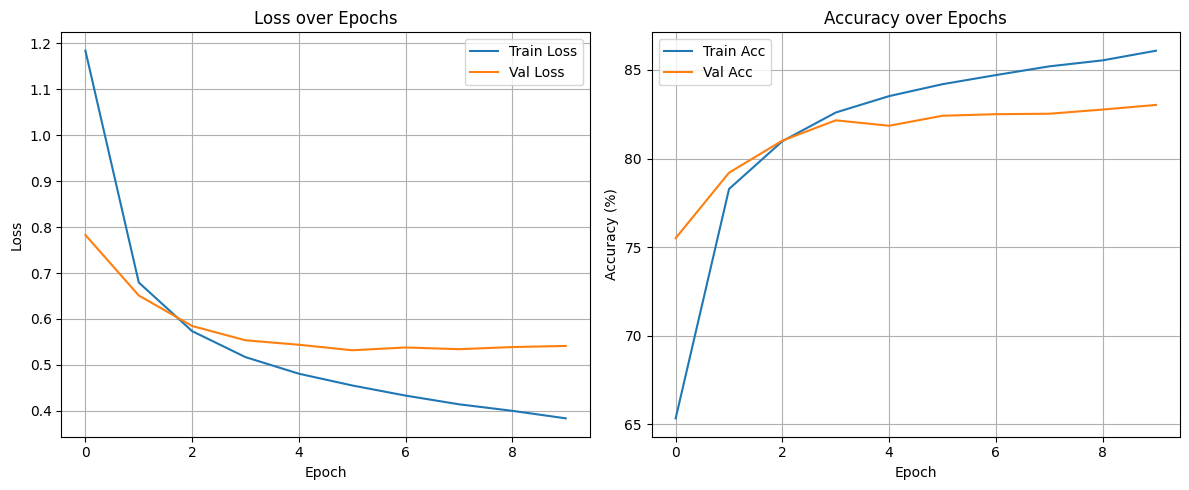

In [18]:
# --- Визуализация истории обучения ---
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('artifacts/figures/training_history.png', dpi=150)
plt.show()

In [19]:
# %% [markdown]
# ### 3. Эксперименты

# %%
# --- Функция обучения с ранней остановкой ---
def train_with_early_stopping(model, train_loader, val_loader, optimizer, criterion, device, max_epochs, patience):
    best_val_acc = 0
    best_model_state = None
    epochs_without_improvement = 0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(max_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Epoch {epoch+1}/{max_epochs} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")
        
        # Проверка улучшения
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
        
        # Ранняя остановка
        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
    
    # Восстанавливаем лучшие веса
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    return history, best_val_acc

# --- Функция логирования в CSV ---
import csv
import os

def log_experiment(experiment_name, config, val_acc, test_acc=None):
    os.makedirs('artifacts', exist_ok=True)
    csv_path = 'artifacts/runs.csv'
    
    file_exists = os.path.exists(csv_path)
    
    with open(csv_path, 'a', newline='') as f:
        writer = csv.writer(f)
        if not file_exists:
            writer.writerow(['experiment', 'config', 'val_accuracy', 'test_accuracy'])
        
        test_acc_str = f"{test_acc:.2f}" if test_acc is not None else "N/A"
        writer.writerow([experiment_name, config, f"{val_acc:.2f}", test_acc_str])
    
    print(f"✓ Logged {experiment_name} to runs.csv")

In [20]:
# %% [markdown]
# ### 3.1. Часть A (S08): Регуляризация

# %% [markdown]
# #### E1: Базовая модель (без регуляризации)

# %%
class MLP_Base(nn.Module):
    def __init__(self, input_size, num_classes):
        super(MLP_Base, self).__init__()
        self.flatten = nn.Flatten()
        self.network = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.network(x)

# Обучение E1
model_e1 = MLP_Base(INPUT_SIZE, NUM_CLASSES).to(device)
optimizer_e1 = optim.Adam(model_e1.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

print("Training E1 (Base MLP)...")
history_e1, val_acc_e1 = train_with_early_stopping(
    model_e1, train_loader, val_loader, optimizer_e1, criterion, device, max_epochs=15, patience=100
)

log_experiment("E1_Base", "512-256-128, Adam, lr=0.001, no reg", val_acc_e1)

Training E1 (Base MLP)...
Epoch 1/15 | Train Acc: 67.29% | Val Acc: 77.20%
Epoch 2/15 | Train Acc: 79.33% | Val Acc: 79.88%
Epoch 3/15 | Train Acc: 81.90% | Val Acc: 81.52%
Epoch 4/15 | Train Acc: 83.44% | Val Acc: 81.63%
Epoch 5/15 | Train Acc: 84.46% | Val Acc: 83.22%
Epoch 6/15 | Train Acc: 85.28% | Val Acc: 82.89%
Epoch 7/15 | Train Acc: 86.02% | Val Acc: 83.57%
Epoch 8/15 | Train Acc: 86.61% | Val Acc: 83.87%
Epoch 9/15 | Train Acc: 87.14% | Val Acc: 83.69%
Epoch 10/15 | Train Acc: 87.60% | Val Acc: 83.83%
Epoch 11/15 | Train Acc: 88.04% | Val Acc: 82.91%
Epoch 12/15 | Train Acc: 88.35% | Val Acc: 83.71%
Epoch 13/15 | Train Acc: 88.80% | Val Acc: 83.58%
Epoch 14/15 | Train Acc: 89.08% | Val Acc: 83.84%
Epoch 15/15 | Train Acc: 89.21% | Val Acc: 83.51%
✓ Logged E1_Base to runs.csv


In [21]:
# %% [markdown]
# ### 3.1. Часть A (S08): Регуляризация

# %% [markdown]
# #### E1: Базовая модель (без регуляризации)

# %%
class MLP_Base(nn.Module):
    def __init__(self, input_size, num_classes):
        super(MLP_Base, self).__init__()
        self.flatten = nn.Flatten()
        self.network = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.network(x)

# Обучение E1
model_e1 = MLP_Base(INPUT_SIZE, NUM_CLASSES).to(device)
optimizer_e1 = optim.Adam(model_e1.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

print("Training E1 (Base MLP)...")
history_e1, val_acc_e1 = train_with_early_stopping(
    model_e1, train_loader, val_loader, optimizer_e1, criterion, device, max_epochs=15, patience=100
)

log_experiment("E1_Base", "512-256-128, Adam, lr=0.001, no reg", val_acc_e1)

Training E1 (Base MLP)...
Epoch 1/15 | Train Acc: 66.91% | Val Acc: 77.26%
Epoch 2/15 | Train Acc: 79.67% | Val Acc: 80.45%
Epoch 3/15 | Train Acc: 82.20% | Val Acc: 82.49%
Epoch 4/15 | Train Acc: 83.63% | Val Acc: 82.74%
Epoch 5/15 | Train Acc: 84.62% | Val Acc: 82.30%
Epoch 6/15 | Train Acc: 85.30% | Val Acc: 83.52%
Epoch 7/15 | Train Acc: 86.14% | Val Acc: 83.85%
Epoch 8/15 | Train Acc: 86.59% | Val Acc: 83.84%
Epoch 9/15 | Train Acc: 87.23% | Val Acc: 84.10%
Epoch 10/15 | Train Acc: 87.62% | Val Acc: 84.00%
Epoch 11/15 | Train Acc: 87.99% | Val Acc: 83.82%
Epoch 12/15 | Train Acc: 88.33% | Val Acc: 83.24%
Epoch 13/15 | Train Acc: 88.68% | Val Acc: 82.93%
Epoch 14/15 | Train Acc: 88.98% | Val Acc: 83.63%
Epoch 15/15 | Train Acc: 89.27% | Val Acc: 83.75%
✓ Logged E1_Base to runs.csv


In [22]:
# %% [markdown]
# #### E2: Dropout (p=0.3)

# %%
class MLP_Dropout(nn.Module):
    def __init__(self, input_size, num_classes, dropout_p=0.3):
        super(MLP_Dropout, self).__init__()
        self.flatten = nn.Flatten()
        self.network = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.network(x)

# Обучение E2
model_e2 = MLP_Dropout(INPUT_SIZE, NUM_CLASSES, dropout_p=0.3).to(device)
optimizer_e2 = optim.Adam(model_e2.parameters(), lr=0.001)

print("Training E2 (Dropout)...")
history_e2, val_acc_e2 = train_with_early_stopping(
    model_e2, train_loader, val_loader, optimizer_e2, criterion, device, max_epochs=15, patience=100
)

log_experiment("E2_Dropout", "512-256-128, Dropout=0.3, Adam, lr=0.001", val_acc_e2)

Training E2 (Dropout)...
Epoch 1/15 | Train Acc: 54.04% | Val Acc: 74.38%
Epoch 2/15 | Train Acc: 68.95% | Val Acc: 77.64%
Epoch 3/15 | Train Acc: 72.02% | Val Acc: 79.38%
Epoch 4/15 | Train Acc: 73.48% | Val Acc: 80.35%
Epoch 5/15 | Train Acc: 74.30% | Val Acc: 80.31%
Epoch 6/15 | Train Acc: 75.40% | Val Acc: 81.62%
Epoch 7/15 | Train Acc: 75.82% | Val Acc: 81.65%
Epoch 8/15 | Train Acc: 76.15% | Val Acc: 82.46%
Epoch 9/15 | Train Acc: 76.57% | Val Acc: 81.46%
Epoch 10/15 | Train Acc: 76.76% | Val Acc: 81.52%
Epoch 11/15 | Train Acc: 77.21% | Val Acc: 82.04%
Epoch 12/15 | Train Acc: 77.38% | Val Acc: 82.42%
Epoch 13/15 | Train Acc: 77.57% | Val Acc: 82.77%
Epoch 14/15 | Train Acc: 77.78% | Val Acc: 82.77%
Epoch 15/15 | Train Acc: 78.04% | Val Acc: 82.19%
✓ Logged E2_Dropout to runs.csv


In [23]:
# %% [markdown]
# #### E3: BatchNorm

# %%
class MLP_BatchNorm(nn.Module):
    def __init__(self, input_size, num_classes):
        super(MLP_BatchNorm, self).__init__()
        self.flatten = nn.Flatten()
        self.network = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.network(x)

# Обучение E3
model_e3 = MLP_BatchNorm(INPUT_SIZE, NUM_CLASSES).to(device)
optimizer_e3 = optim.Adam(model_e3.parameters(), lr=0.001)

print("Training E3 (BatchNorm)...")
history_e3, val_acc_e3 = train_with_early_stopping(
    model_e3, train_loader, val_loader, optimizer_e3, criterion, device, max_epochs=15, patience=100
)

log_experiment("E3_BatchNorm", "512-256-128, BatchNorm, Adam, lr=0.001", val_acc_e3)

Training E3 (BatchNorm)...
Epoch 1/15 | Train Acc: 74.64% | Val Acc: 81.76%
Epoch 2/15 | Train Acc: 82.45% | Val Acc: 83.55%
Epoch 3/15 | Train Acc: 84.68% | Val Acc: 85.04%
Epoch 4/15 | Train Acc: 85.81% | Val Acc: 85.34%
Epoch 5/15 | Train Acc: 86.85% | Val Acc: 85.22%
Epoch 6/15 | Train Acc: 87.55% | Val Acc: 84.88%
Epoch 7/15 | Train Acc: 88.27% | Val Acc: 85.50%
Epoch 8/15 | Train Acc: 88.79% | Val Acc: 85.74%
Epoch 9/15 | Train Acc: 89.32% | Val Acc: 85.56%
Epoch 10/15 | Train Acc: 89.86% | Val Acc: 86.12%
Epoch 11/15 | Train Acc: 90.21% | Val Acc: 85.83%
Epoch 12/15 | Train Acc: 90.73% | Val Acc: 85.99%
Epoch 13/15 | Train Acc: 90.94% | Val Acc: 85.35%
Epoch 14/15 | Train Acc: 91.21% | Val Acc: 85.72%
Epoch 15/15 | Train Acc: 91.55% | Val Acc: 85.68%
✓ Logged E3_BatchNorm to runs.csv


In [24]:
# %% [markdown]
# #### E4: Ранняя остановка (лучший из E2/E3)

# %%
# Выбираем лучший вариант
if val_acc_e2 >= val_acc_e3:
    print(f"E2 лучше (Val Acc: {val_acc_e2:.2f}%) → используем Dropout для E4")
    best_model_class = MLP_Dropout
    best_config = "Dropout"
else:
    print(f"E3 лучше (Val Acc: {val_acc_e3:.2f}%) → используем BatchNorm для E4")
    best_model_class = MLP_BatchNorm
    best_config = "BatchNorm"

# Обучение E4 с ранней остановкой
model_e4 = best_model_class(INPUT_SIZE, NUM_CLASSES).to(device)
optimizer_e4 = optim.Adam(model_e4.parameters(), lr=0.001)

print(f"Training E4 (Early Stopping with {best_config})...")
history_e4, val_acc_e4 = train_with_early_stopping(
    model_e4, train_loader, val_loader, optimizer_e4, criterion, device, max_epochs=30, patience=5
)

# Тестирование на test set
test_loss, test_acc_e4 = evaluate(model_e4, test_loader, criterion, device)
print(f"E4 Test Accuracy: {test_acc_e4:.2f}%")

log_experiment("E4_EarlyStop", f"512-256-128, {best_config}, Early Stop(patience=5)", val_acc_e4, test_acc_e4)

# Сохранение лучшей модели
os.makedirs('artifacts', exist_ok=True)
torch.save(model_e4.state_dict(), 'artifacts/best_model.pt')
print("Saved best_model.pt")

E3 лучше (Val Acc: 86.12%) → используем BatchNorm для E4
Training E4 (Early Stopping with BatchNorm)...
Epoch 1/30 | Train Acc: 74.65% | Val Acc: 81.96%
Epoch 2/30 | Train Acc: 82.36% | Val Acc: 83.61%
Epoch 3/30 | Train Acc: 84.46% | Val Acc: 83.73%
Epoch 4/30 | Train Acc: 85.91% | Val Acc: 85.02%
Epoch 5/30 | Train Acc: 86.75% | Val Acc: 85.66%
Epoch 6/30 | Train Acc: 87.67% | Val Acc: 85.28%
Epoch 7/30 | Train Acc: 88.36% | Val Acc: 85.65%
Epoch 8/30 | Train Acc: 88.75% | Val Acc: 85.35%
Epoch 9/30 | Train Acc: 89.34% | Val Acc: 85.61%
Epoch 10/30 | Train Acc: 89.98% | Val Acc: 85.43%
Early stopping at epoch 10
E4 Test Accuracy: 85.29%
✓ Logged E4_EarlyStop to runs.csv
Saved best_model.pt


In [25]:
# %% [markdown]
# ### 3.2. Часть B (S09): LR, оптимизаторы, weight decay

# %% [markdown]
# #### O1: LR слишком высокий (1e-1)

# %%
model_o1 = best_model_class(INPUT_SIZE, NUM_CLASSES).to(device)
optimizer_o1 = optim.Adam(model_o1.parameters(), lr=0.1)  # Слишком высокий LR

print("Training O1 (LR too high)...")
history_o1, val_acc_o1 = train_with_early_stopping(
    model_o1, train_loader, val_loader, optimizer_o1, criterion, device, max_epochs=8, patience=100
)

log_experiment("O1_LR_High", "Adam, lr=0.1", val_acc_o1)

Training O1 (LR too high)...
Epoch 1/8 | Train Acc: 63.79% | Val Acc: 73.33%
Epoch 2/8 | Train Acc: 73.71% | Val Acc: 77.51%
Epoch 3/8 | Train Acc: 76.28% | Val Acc: 78.10%
Epoch 4/8 | Train Acc: 77.62% | Val Acc: 77.73%
Epoch 5/8 | Train Acc: 78.82% | Val Acc: 79.99%
Epoch 6/8 | Train Acc: 79.47% | Val Acc: 80.87%
Epoch 7/8 | Train Acc: 80.36% | Val Acc: 81.16%
Epoch 8/8 | Train Acc: 81.01% | Val Acc: 80.25%
✓ Logged O1_LR_High to runs.csv


In [26]:
# %% [markdown]
# #### O2: LR слишком низкий (1e-5)

# %%
model_o2 = best_model_class(INPUT_SIZE, NUM_CLASSES).to(device)
optimizer_o2 = optim.Adam(model_o2.parameters(), lr=1e-5)  # Слишком низкий LR

print("Training O2 (LR too low)...")
history_o2, val_acc_o2 = train_with_early_stopping(
    model_o2, train_loader, val_loader, optimizer_o2, criterion, device, max_epochs=8, patience=100
)

log_experiment("O2_LR_Low", "Adam, lr=1e-5", val_acc_o2)

Training O2 (LR too low)...
Epoch 1/8 | Train Acc: 31.99% | Val Acc: 51.21%
Epoch 2/8 | Train Acc: 55.82% | Val Acc: 61.64%
Epoch 3/8 | Train Acc: 63.50% | Val Acc: 66.94%
Epoch 4/8 | Train Acc: 68.11% | Val Acc: 70.44%
Epoch 5/8 | Train Acc: 71.18% | Val Acc: 72.77%
Epoch 6/8 | Train Acc: 73.32% | Val Acc: 74.66%
Epoch 7/8 | Train Acc: 75.20% | Val Acc: 76.29%
Epoch 8/8 | Train Acc: 76.52% | Val Acc: 77.44%
✓ Logged O2_LR_Low to runs.csv


In [27]:
# %% [markdown]
# #### O3: SGD + Momentum + Weight Decay

# %%
model_o3 = best_model_class(INPUT_SIZE, NUM_CLASSES).to(device)
optimizer_o3 = optim.SGD(model_o3.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)

print("Training O3 (SGD + Momentum + WD)...")
history_o3, val_acc_o3 = train_with_early_stopping(
    model_o3, train_loader, val_loader, optimizer_o3, criterion, device, max_epochs=15, patience=100
)

log_experiment("O3_SGD_WD", "SGD, lr=0.01, momentum=0.9, WD=1e-4", val_acc_o3)

Training O3 (SGD + Momentum + WD)...
Epoch 1/15 | Train Acc: 73.29% | Val Acc: 80.82%
Epoch 2/15 | Train Acc: 82.10% | Val Acc: 83.74%
Epoch 3/15 | Train Acc: 84.41% | Val Acc: 84.44%
Epoch 4/15 | Train Acc: 85.85% | Val Acc: 85.04%
Epoch 5/15 | Train Acc: 86.71% | Val Acc: 85.35%
Epoch 6/15 | Train Acc: 87.51% | Val Acc: 85.63%
Epoch 7/15 | Train Acc: 88.07% | Val Acc: 85.56%
Epoch 8/15 | Train Acc: 88.58% | Val Acc: 85.57%
Epoch 9/15 | Train Acc: 89.18% | Val Acc: 85.31%
Epoch 10/15 | Train Acc: 89.52% | Val Acc: 85.21%
Epoch 11/15 | Train Acc: 90.05% | Val Acc: 85.36%
Epoch 12/15 | Train Acc: 90.42% | Val Acc: 85.38%
Epoch 13/15 | Train Acc: 90.71% | Val Acc: 85.47%
Epoch 14/15 | Train Acc: 90.99% | Val Acc: 85.10%
Epoch 15/15 | Train Acc: 91.19% | Val Acc: 85.35%
✓ Logged O3_SGD_WD to runs.csv


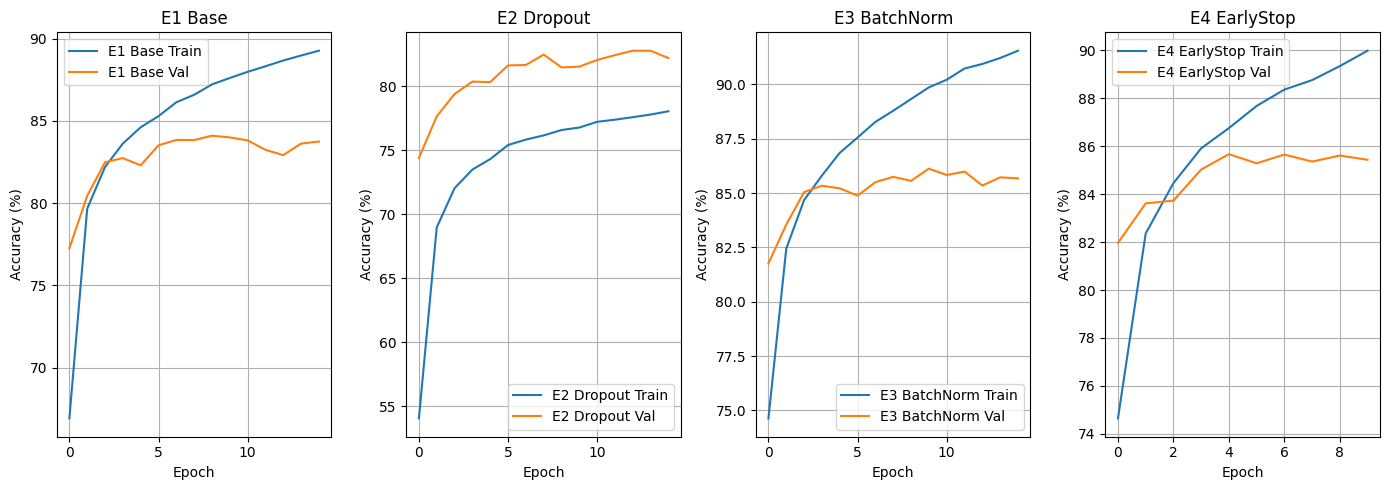

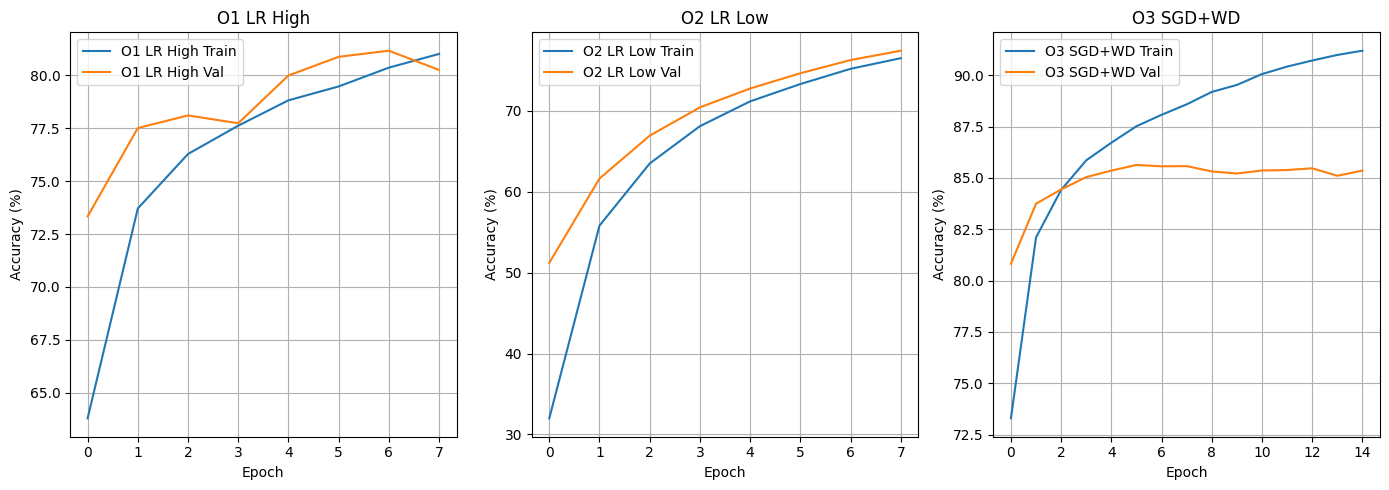

In [28]:
# %% [markdown]
# ### Визуализация результатов экспериментов

# %%
def plot_experiment_comparison(histories, titles, ylabel, filename):
    plt.figure(figsize=(14, 5))
    
    for i, (hist, title) in enumerate(zip(histories, titles)):
        plt.subplot(1, len(histories), i+1)
        for key, label in [('train_acc', 'Train'), ('val_acc', 'Val')]:
            if key in hist:
                plt.plot(hist[key], label=f"{title} {label}")
        plt.title(title)
        plt.xlabel('Epoch')
        plt.ylabel(ylabel)
        plt.legend()
        plt.grid(True)
    
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()

# Графики для Части A
plot_experiment_comparison(
    [history_e1, history_e2, history_e3, history_e4],
    ['E1 Base', 'E2 Dropout', 'E3 BatchNorm', 'E4 EarlyStop'],
    'Accuracy (%)',
    'artifacts/figures/partA_comparison.png'
)

# Графики для Части B
plot_experiment_comparison(
    [history_o1, history_o2, history_o3],
    ['O1 LR High', 'O2 LR Low', 'O3 SGD+WD'],
    'Accuracy (%)',
    'artifacts/figures/partB_comparison.png'
)

In [29]:
# %%
# Чтение и отображение runs.csv
import pandas as pd

if os.path.exists('artifacts/runs.csv'):
    df = pd.read_csv('artifacts/runs.csv')
    print("\n=== Все эксперименты ===")
    display(df)
else:
    print("runs.csv не найден")


=== Все эксперименты ===


,experiment,config,val_accuracy,test_accuracy
0,E1_Base,"512-256-128, Adam, lr=0.001, no reg",83.87,NaN
1,E1_Base,"512-256-128, Adam, lr=0.001, no reg",84.10,NaN
2,E2_Dropout,"512-256-128, Dropout=0.3, Adam, lr=0.001",82.77,NaN
3,E3_BatchNorm,"512-256-128, BatchNorm, Adam, lr=0.001",86.12,NaN
4,E4_EarlyStop,"512-256-128, BatchNorm, Early Stop(patience=5)",85.66,85.29
5,O1_LR_High,"Adam, lr=0.1",81.16,NaN
6,O2_LR_Low,"Adam, lr=1e-5",77.44,NaN
7,O3_SGD_WD,"SGD, lr=0.01, momentum=0.9, WD=1e-4",85.63,NaN


In [30]:
# %% [markdown]
# # 4. Артефакты: запуск экспериментов и сохранение результатов (EMNIST balanced)

# %%
import os
import json
import csv
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

# === Настройки ===
os.makedirs("artifacts/figures", exist_ok=True)
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

runs_results = []

# === Вспомогательные функции ===
def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        # EMNIST balanced: метки уже 0..46, сдвиг не нужен
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * y.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        # Метки уже 0..46
        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item() * y.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)
    return total_loss / total, correct / total

def plot_curves(history, title, save_path):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax1.plot(epochs, history['train_loss'], label='Train Loss', color='blue')
    ax1.plot(epochs, history['val_loss'], label='Val Loss', color='red')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.tick_params(axis='y')
    ax2 = ax1.twinx()
    ax2.plot(epochs, history['train_acc'], label='Train Acc', color='blue', linestyle='--')
    ax2.plot(epochs, history['val_acc'], label='Val Acc', color='red', linestyle='--')
    ax2.set_ylabel('Accuracy')
    ax2.tick_params(axis='y')
    plt.title(title)
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.close()

# === Загрузка EMNIST ===
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

print("Загрузка EMNIST balanced...")
train_full = torchvision.datasets.EMNIST(
    root='./data', split='balanced', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.EMNIST(
    root='./data', split='balanced', train=False, download=True, transform=transform
)

NUM_CLASSES = 47
INPUT_SIZE = 28 * 28

val_ratio = 0.2
train_size = int((1 - val_ratio) * len(train_full))
val_size = len(train_full) - train_size
train_dataset, val_dataset = random_split(
    train_full, [train_size, val_size], generator=torch.Generator().manual_seed(SEED)
)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"EMNIST: train={len(train_dataset)}, val={len(val_dataset)}, test={len(test_dataset)}")

# === Модель ===
class MLP(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size, activation='relu', 
                 dropout_p=0.0, use_batchnorm=False):
        super().__init__()
        layers = [nn.Flatten()]
        sizes = [input_size] + hidden_sizes
        act_fn = nn.ReLU() if activation == 'relu' else nn.Tanh()
        
        for i in range(len(sizes) - 1):
            layers.append(nn.Linear(sizes[i], sizes[i+1]))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(sizes[i+1]))
            layers.append(act_fn)
            if dropout_p > 0 and i < len(sizes) - 2:
                layers.append(nn.Dropout(dropout_p))
        layers.append(nn.Linear(sizes[-1], output_size))
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)
    
    def get_summary(self, hidden_sizes, activation, dropout_p, use_batchnorm):
        parts = [str(hidden_sizes), activation]
        if dropout_p > 0:
            parts.append(f"Drop{dropout_p}")
        if use_batchnorm:
            parts.append("BN")
        return "/".join(parts)

# === Запуск эксперимента ===
def run_experiment(exp_id, dataset_name, seed, hidden_sizes, activation, dropout_p, use_batchnorm,
                   optimizer_name, lr, momentum, weight_decay, epochs, early_stop_patience=None):
    set_seed(seed)
    
    model = MLP(INPUT_SIZE, hidden_sizes, NUM_CLASSES, activation, dropout_p, use_batchnorm).to(device)
    criterion = nn.CrossEntropyLoss()
    
    if optimizer_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = -1
    best_model_state = None
    patience_counter = 0
    epochs_trained = 0
    
    for epoch in range(epochs):
        epochs_trained = epoch + 1
        t_loss, t_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        v_loss, v_acc = evaluate(model, val_loader, criterion, device)
        
        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)
        
        if v_acc > best_val_acc:
            best_val_acc = v_acc
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
        
        if early_stop_patience and patience_counter >= early_stop_patience:
            print(f"  Early stopping at epoch {epochs_trained}")
            break
    
    return {
        'experiment_id': exp_id,
        'dataset': dataset_name,
        'seed': seed,
        'model_summary': model.get_summary(hidden_sizes, activation, dropout_p, use_batchnorm),
        'optimizer': optimizer_name,
        'lr': lr,
        'momentum': momentum if optimizer_name == 'SGD' else 0,
        'weight_decay': weight_decay,
        'epochs_trained': epochs_trained,
        'best_val_accuracy': best_val_acc,
        'best_val_loss': min(history['val_loss']),
        'history': history,
        'best_model_state': best_model_state,
        '_hidden_sizes': hidden_sizes,
        '_dropout': dropout_p,
        '_batchnorm': use_batchnorm
    }

# === Конфигурации ===
experiments = [
    {'id': 'E1', 'hidden': [512, 256], 'activation': 'relu', 'dropout': 0.0, 'bn': False, 
     'opt': 'Adam', 'lr': 1e-3, 'momentum': 0, 'wd': 0, 'epochs': 15, 'early_stop': None},
    {'id': 'E2', 'hidden': [512, 256], 'activation': 'relu', 'dropout': 0.3, 'bn': False, 
     'opt': 'Adam', 'lr': 1e-3, 'momentum': 0, 'wd': 0, 'epochs': 15, 'early_stop': None},
    {'id': 'E3', 'hidden': [512, 256], 'activation': 'relu', 'dropout': 0.0, 'bn': True, 
     'opt': 'Adam', 'lr': 1e-3, 'momentum': 0, 'wd': 0, 'epochs': 15, 'early_stop': None},
    {'id': 'O1', 'hidden': [512, 256], 'activation': 'relu', 'dropout': 0.3, 'bn': False, 
     'opt': 'Adam', 'lr': 1e-1, 'momentum': 0, 'wd': 0, 'epochs': 6, 'early_stop': None},
    {'id': 'O2', 'hidden': [512, 256], 'activation': 'relu', 'dropout': 0.3, 'bn': False, 
     'opt': 'Adam', 'lr': 1e-5, 'momentum': 0, 'wd': 0, 'epochs': 6, 'early_stop': None},
    {'id': 'O3', 'hidden': [512, 256], 'activation': 'relu', 'dropout': 0.3, 'bn': False, 
     'opt': 'SGD', 'lr': 1e-2, 'momentum': 0.9, 'wd': 1e-4, 'epochs': 12, 'early_stop': None},
]

# === Запуск ===
print("Запуск экспериментов (EMNIST balanced)...")

# E1-E3
for cfg in experiments[:3]:
    print(f"\n[{cfg['id']}] Запуск...")
    res = run_experiment(
        exp_id=cfg['id'], dataset_name='EMNIST', seed=SEED,
        hidden_sizes=cfg['hidden'], activation=cfg['activation'],
        dropout_p=cfg['dropout'], use_batchnorm=cfg['bn'],
        optimizer_name=cfg['opt'], lr=cfg['lr'], momentum=cfg['momentum'],
        weight_decay=cfg['wd'], epochs=cfg['epochs'], early_stop_patience=cfg['early_stop']
    )
    runs_results.append(res)
    print(f"  [{cfg['id']}]: val_acc={res['best_val_accuracy']:.4f}")

# Выбор лучшей из E2/E3 для E4
best_e2e3 = max([r for r in runs_results if r['experiment_id'] in ['E2', 'E3']], key=lambda x: x['best_val_accuracy'])
print(f"\nЛучшая из E2/E3: {best_e2e3['experiment_id']} (val_acc={best_e2e3['best_val_accuracy']:.4f})")

# E4 с early stopping
print(f"\n[E4] Запуск с early stopping...")
e4_dropout = 0.3 if best_e2e3['experiment_id'] == 'E2' else 0.0
e4_bn = best_e2e3['experiment_id'] == 'E3'
e4_res = run_experiment(
    exp_id='E4', dataset_name='EMNIST', seed=SEED,
    hidden_sizes=[512, 256], activation='relu',
    dropout_p=e4_dropout, use_batchnorm=e4_bn,
    optimizer_name='Adam', lr=1e-3, momentum=0, weight_decay=0,
    epochs=40, early_stop_patience=5
)
runs_results.append(e4_res)
print(f"  [E4]: val_acc={e4_res['best_val_accuracy']:.4f}, epochs={e4_res['epochs_trained']}")

# O1-O3
for cfg in experiments[3:]:
    print(f"\n[{cfg['id']}] Запуск...")
    res = run_experiment(
        exp_id=cfg['id'], dataset_name='EMNIST', seed=SEED,
        hidden_sizes=cfg['hidden'], activation=cfg['activation'],
        dropout_p=cfg['dropout'], use_batchnorm=cfg['bn'],
        optimizer_name=cfg['opt'], lr=cfg['lr'], momentum=cfg['momentum'],
        weight_decay=cfg['wd'], epochs=cfg['epochs'], early_stop_patience=cfg['early_stop']
    )
    runs_results.append(res)
    print(f"  [{cfg['id']}]: val_acc={res['best_val_accuracy']:.4f}")

# === Сохранение runs.csv ===
print("\nСохранение runs.csv...")
with open("artifacts/runs.csv", "w", newline='', encoding='utf-8') as f:
    fieldnames = ['experiment_id', 'dataset', 'seed', 'model_summary', 'optimizer', 
                  'lr', 'momentum', 'weight_decay', 'epochs_trained', 
                  'best_val_accuracy', 'best_val_loss']
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    for r in runs_results:
        row = {k: r[k] for k in fieldnames}
        writer.writerow(row)

# === Сохранение best_model.pt и best_config.json ===
print("Сохранение best_model.pt и best_config.json...")
best_exp = next(r for r in runs_results if r['experiment_id'] == 'E4')
torch.save(best_exp['best_model_state'], "artifacts/best_model.pt")

config = {
    "experiment_id": "E4",
    "dataset": "EMNIST",
    "split": "balanced",
    "seed": SEED,
    "architecture": {
        "input_size": INPUT_SIZE,
        "hidden_sizes": best_exp['_hidden_sizes'],
        "output_classes": NUM_CLASSES,
        "activation": "relu",
        "dropout": best_exp['_dropout'],
        "batchnorm": best_exp['_batchnorm']
    },
    "training": {
        "optimizer": "Adam",
        "lr": 1e-3,
        "weight_decay": 0,
        "early_stopping_patience": 5
    },
    "results": {
        "best_val_accuracy": best_exp['best_val_accuracy'],
        "best_val_loss": best_exp['best_val_loss'],
        "epochs_trained": best_exp['epochs_trained']
    }
}
with open("artifacts/best_config.json", "w", encoding='utf-8') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

# === Графики ===
print("Построение curves_best.png...")
plot_curves(best_exp['history'], "Training Curves - Best Model (E4, EMNIST)", "artifacts/figures/curves_best.png")

print("Построение curves_lr_extremes.png...")
o1_res = next(r for r in runs_results if r['experiment_id'] == 'O1')
o2_res = next(r for r in runs_results if r['experiment_id'] == 'O2')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(o1_res['history']['val_loss'], label='Val Loss', color='red', marker='o')
ax1.plot(o1_res['history']['train_loss'], label='Train Loss', color='blue', marker='o')
ax1.set_title("O1: LR too large (1e-1)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(o2_res['history']['val_loss'], label='Val Loss', color='red', marker='o')
ax2.plot(o2_res['history']['train_loss'], label='Train Loss', color='blue', marker='o')
ax2.set_title("O2: LR too small (1e-5)")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("artifacts/figures/curves_lr_extremes.png", dpi=150)
plt.close()

print("\nВсе артефакты сохранены в artifacts/")

Device: cpu
Загрузка EMNIST balanced...
EMNIST: train=90240, val=22560, test=18800
Запуск экспериментов (EMNIST balanced)...

[E1] Запуск...
  [E1]: val_acc=0.8431

[E2] Запуск...
  [E2]: val_acc=0.8472

[E3] Запуск...
  [E3]: val_acc=0.8568

Лучшая из E2/E3: E3 (val_acc=0.8568)

[E4] Запуск с early stopping...
  Early stopping at epoch 14
  [E4]: val_acc=0.8568, epochs=14

[O1] Запуск...
  [O1]: val_acc=0.0217

[O2] Запуск...
  [O2]: val_acc=0.6633

[O3] Запуск...
  [O3]: val_acc=0.8557

Сохранение runs.csv...
Сохранение best_model.pt и best_config.json...
Построение curves_best.png...
Построение curves_lr_extremes.png...

Все артефакты сохранены в artifacts/


In [31]:
with open("artifacts/runs.csv", "r", encoding="utf-8") as f:
    print(f.read())

experiment_id,dataset,seed,model_summary,optimizer,lr,momentum,weight_decay,epochs_trained,best_val_accuracy,best_val_loss
E1,EMNIST,42,"[512, 256]/relu",Adam,0.001,0,0,15,0.8431294326241134,0.4966351350148519
E2,EMNIST,42,"[512, 256]/relu/Drop0.3",Adam,0.001,0,0,15,0.8472074468085107,0.47820265314257737
E3,EMNIST,42,"[512, 256]/relu/BN",Adam,0.001,0,0,15,0.8568262411347518,0.433732142051061
E4,EMNIST,42,"[512, 256]/relu/BN",Adam,0.001,0,0,14,0.8568262411347518,0.433732142051061
O1,EMNIST,42,"[512, 256]/relu/Drop0.3",Adam,0.1,0,0,6,0.021675531914893617,3.8644482152681823
O2,EMNIST,42,"[512, 256]/relu/Drop0.3",Adam,1e-05,0,0,6,0.6633421985815603,1.210210295771876
O3,EMNIST,42,"[512, 256]/relu/Drop0.3",SGD,0.01,0.9,0.0001,12,0.855718085106383,0.42837720779662436



In [33]:
# Финальная оценка на test-наборе
@torch.no_grad()
def evaluate_on_test(model, test_loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item() * y.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)
    return total_loss / total, correct / total

# Загрузка лучшей модели и оценка
best_model = MLP(INPUT_SIZE, [512, 256], NUM_CLASSES, activation='relu', dropout_p=0.0, use_batchnorm=True).to(device)
best_model.load_state_dict(torch.load("artifacts/best_model.pt", map_location=device))
test_loss, test_acc = evaluate_on_test(best_model, test_loader, criterion, device)
print(f"Final test accuracy: {test_acc:.4f}")

Final test accuracy: 0.8509


In [34]:
# Sanity-check
x_batch, y_batch = next(iter(train_loader))
print(f"x_batch shape: {x_batch.shape}, range: [{x_batch.min():.3f}, {x_batch.max():.3f}]")
print(f"y_batch shape: {y_batch.shape}, unique labels: {torch.unique(y_batch)}")

x_batch shape: torch.Size([64, 1, 28, 28]), range: [-0.424, 2.821]
y_batch shape: torch.Size([64]), unique labels: tensor([ 0,  1,  2,  3,  5,  6,  8,  9, 10, 11, 15, 16, 17, 18, 19, 21, 23, 24,
        25, 26, 27, 29, 31, 32, 34, 35, 36, 37, 38, 39, 40, 41, 42, 44, 46])
